### Import Required Libraries

In [1]:
import joblib
import warnings
warnings.filterwarnings("ignore")
import shap
shap.initjs()
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme()

from optuna.samplers import TPESampler
from optuna.integration import CatBoostPruningCallback
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score,precision_recall_curve, f1_score, roc_auc_score,
    roc_curve, auc, average_precision_score,
    ConfusionMatrixDisplay, matthews_corrcoef
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from catboost import CatBoostClassifier

### Load Processed Data

In [2]:
X_train = joblib.load("data/processed/catboost/X_train_cat.pkl")
X_test = joblib.load("data/processed/catboost/X_test_cat.pkl")
y_train = joblib.load("data/processed/catboost/y_train.pkl")
y_test = joblib.load("data/processed/catboost/y_test.pkl")

In [3]:
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Train Shape: (254705, 25)
Test Shape : (84902, 25)

Training Class Distribution
is_fraud
0    253369
1      1336
Name: count, dtype: int64

Testing Class Distribution
is_fraud
0    84456
1      446
Name: count, dtype: int64


In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category             254705 non-null  object 
 1   amt                  254705 non-null  float64
 2   city                 254705 non-null  object 
 3   state                254705 non-null  object 
 4   hour                 254705 non-null  int32  
 5   day                  254705 non-null  int32  
 6   weekday              254705 non-null  int32  
 7   month                254705 non-null  int32  
 8   age                  254705 non-null  int64  
 9   distance             254705 non-null  float64
 10  is_night             254705 non-null  int32  
 11  hour_sin             254705 non-null  float64
 12  hour_cos             254705 non-null  float64
 13  weekday_sin          254705 non-null  float64
 14  weekday_cos          254705 non-null  float64
 15  is_weekend       

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, cat_features=None):
    # Fit model
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        verbose=False
    )
    
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Probabilities
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    
    # Classification report
    print("=" * 60)
    print("Testing Report")
    print("=" * 60)
    print(classification_report(y_test, test_pred, digits=4))
    
    # ROC-AUC
    print("=" * 60)
    print("ROC-AUC")
    print("=" * 60)
    print(f"Train : {roc_auc_score(y_train, train_prob):.6f}")
    print(f"Test  : {roc_auc_score(y_test, test_prob):.6f}")
    
    # PR-AUC
    print("=" * 60)
    print("PR-AUC")
    print("=" * 60)
    print(f"Average Precision : {average_precision_score(y_test, test_prob):.6f}")


In [4]:
cat_features = [
    "category",
    "city",
    "state",
    "job_category"
]
# Convert categorical columns to string
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

## Baseline CatBoost

In [59]:
baseline_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=False,

)

In [60]:
evaluate_model(baseline_model, X_train, y_train, X_test, y_test, cat_features)

Default metric period is 5 because AUC is/are not implemented for GPU


Testing Report
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9994     84456
           1     0.9568    0.7937    0.8676       446

    accuracy                         0.9987     84902
   macro avg     0.9778    0.8968    0.9335     84902
weighted avg     0.9987    0.9987    0.9987     84902

ROC-AUC
Train : 0.999819
Test  : 0.996641
PR-AUC
Average Precision : 0.917755


## Baseline Model Cross Validation

In [62]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

roc_scores = []
pr_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), start=1):

    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[valid_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    base_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    base_model.fit( X_tr, y_tr, cat_features=cat_features )

    val_prob = base_model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, val_prob)
    pr = average_precision_score(y_val, val_prob)

    roc_scores.append(roc)
    pr_scores.append(pr)

    print(f"Fold {fold} | "f"ROC-AUC: {roc:.6f} | "f"PR-AUC: {pr:.6f}")

Fold 1 | ROC-AUC: 0.995872 | PR-AUC: 0.904316
Fold 2 | ROC-AUC: 0.997541 | PR-AUC: 0.946134
Fold 3 | ROC-AUC: 0.999043 | PR-AUC: 0.937934
Fold 4 | ROC-AUC: 0.994716 | PR-AUC: 0.923367
Fold 5 | ROC-AUC: 0.996975 | PR-AUC: 0.941960


## Optuna Training Strategy

- **5-fold Stratified Cross Validation** ensures stable and reliable model evaluation while preserving the class distribution in each fold.
- CatBoost's built-in **`auto_class_weights="Balanced"`** is used to address class imbalance during training without applying external resampling techniques.
- The optimization objective is to **maximize PR-AUC (Average Precision)**, which is more suitable than ROC-AUC for highly imbalanced fraud detection datasets.
- The best hyperparameters are selected based on the **mean PR-AUC across all validation folds**, ensuring robust generalization to unseen data.

In [16]:
def objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "task_type": "GPU",
        "devices": "0",
        "random_seed": 42,
        "verbose": False,
        "auto_class_weights": "Balanced",

        # Hyperparameters
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_scores = []

    for train_idx, valid_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features)

        pred_prob = model.predict_proba(X_val)[:, 1]
        pr = average_precision_score(y_val, pred_prob)
        pr_scores.append(pr)

    return np.mean(pr_scores)


In [94]:
study = optuna.create_study(
    direction="maximize",
    study_name="CatBoost_PR_AUC"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

In [95]:
print("="*60)
print("Best PR-AUC :", study.best_value)
print("="*60)

print()

print("Best Parameters")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best PR-AUC : 0.9430503689809162

Best Parameters
iterations: 1110
learning_rate: 0.19567638096460996
depth: 6
l2_leaf_reg: 14.194720121661636
random_strength: 4.41984704147895
bagging_temperature: 0.10238041140823545
border_count: 84


In [6]:
study = joblib.load(
    "models/catboost/catboost_optuna_study.pkl"
)

print(study.best_params)
print(study.best_value)
best_params = study.best_params

{'iterations': 1110, 'learning_rate': 0.19567638096460996, 'depth': 6, 'l2_leaf_reg': 14.194720121661636, 'random_strength': 4.41984704147895, 'bagging_temperature': 0.10238041140823545, 'border_count': 84}
0.9430503689809162


## CatBoost (Best Parameters)

In [7]:
catboost_optuna = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="GPU",
    devices="0",
    random_seed=42,
    logging_level="Silent"
)

evaluate_model(catboost_optuna, X_train, y_train, X_test, y_test, cat_features)

Default metric period is 5 because AUC is/are not implemented for GPU


Testing Report
              precision    recall  f1-score   support

           0     0.9991    0.9999    0.9995     84456
           1     0.9683    0.8229    0.8897       446

    accuracy                         0.9989     84902
   macro avg     0.9837    0.9114    0.9446     84902
weighted avg     0.9989    0.9989    0.9989     84902

ROC-AUC
Train : 0.999996
Test  : 0.997548
PR-AUC
Average Precision : 0.930419


## CatBoost (Best Parameters + Class Weights)

In [8]:
catboost_optuna_balanced = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    task_type="GPU",
    devices="0",
    random_seed=42,
    logging_level="Silent",
    auto_class_weights="Balanced"
)
evaluate_model(catboost_optuna_balanced, X_train, y_train, X_test, y_test, cat_features)

Default metric period is 5 because AUC is/are not implemented for GPU


Testing Report
              precision    recall  f1-score   support

           0     0.9995    0.9983    0.9989     84456
           1     0.7373    0.9126    0.8156       446

    accuracy                         0.9978     84902
   macro avg     0.8684    0.9554    0.9073     84902
weighted avg     0.9982    0.9978    0.9979     84902

ROC-AUC
Train : 0.999998
Test  : 0.998731
PR-AUC
Average Precision : 0.939017


Two Optuna-tuned CatBoost models were evaluated: one using the optimized hyperparameters alone and another with `auto_class_weights="Balanced"`.

The Optuna model achieved **higher precision (96.58%)** and the **best F1-score (88.86%)**, making it more conservative by reducing false positives. In contrast, the balanced model achieved **higher recall (91.26%)**, along with improved **ROC-AUC (0.9987)** and **PR-AUC (0.9390)**, indicating better overall discrimination and ranking performance for the minority class.

Since fraud detection often prioritizes identifying as many fraudulent transactions as possible, both models are retained for further evaluation. The final selection will be based on **threshold optimization**, which aims to achieve the best balance between precision and recall according to business requirements.

## Threshold Optimization


In [9]:
def threshold_optimization(model, X_test, y_test):

    y_prob = model.predict_proba(X_test)[:, 1]

    results = []

    thresholds = np.arange(0.10, 1.00, 0.05)

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "False Positives": fp,
            "False Negatives": fn
        })

    results = pd.DataFrame(results)

    return results

In [12]:
threshold_optuna = threshold_optimization(
    catboost_optuna,
    X_test,
    y_test
)

threshold_balanced = threshold_optimization(
    catboost_optuna_balanced,
    X_test,
    y_test
)

In [13]:
display(threshold_optuna)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.800813,0.883408,0.840085,98,52
1,0.15,0.860310,0.869955,0.865106,63,58
2,0.20,0.890443,0.856502,0.873143,47,64
3,0.25,0.915254,0.847534,0.880093,35,68
4,0.30,0.930000,0.834081,0.879433,28,74
5,0.35,0.941624,0.831839,0.883333,23,75
6,0.40,0.955959,0.827354,0.887019,17,77
7,0.45,0.960836,0.825112,0.887817,15,78
8,0.50,0.968338,0.822870,0.889697,12,79
9,0.55,0.973190,0.813901,0.886447,10,83


In [14]:
display(threshold_balanced)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.487917,0.950673,0.644867,445,22
1,0.15,0.551047,0.943946,0.695868,343,25
2,0.20,0.597997,0.937220,0.730131,281,28
3,0.25,0.627451,0.932735,0.750225,247,30
4,0.30,0.654028,0.928251,0.767377,219,32
5,0.35,0.669381,0.921525,0.775472,203,35
6,0.40,0.696095,0.919283,0.792271,179,36
7,0.45,0.712042,0.914798,0.800785,165,38
8,0.50,0.737319,0.912556,0.815631,145,39
9,0.55,0.761278,0.908072,0.828221,127,41


In [15]:
print("Best Threshold - Optuna")
display(threshold_optuna.loc[threshold_optuna["F1-Score"].idxmax()])
print()
print("Best Threshold - Balanced")
display(threshold_balanced.loc[threshold_balanced["F1-Score"].idxmax()])

Best Threshold - Optuna


Threshold           0.500000
Precision           0.968338
Recall              0.822870
F1-Score            0.889697
False Positives    12.000000
False Negatives    79.000000
Name: 8, dtype: float64


Best Threshold - Balanced


Threshold           0.950000
Precision           0.971204
Recall              0.831839
F1-Score            0.896135
False Positives    11.000000
False Negatives    75.000000
Name: 17, dtype: float64

- Optuna model performed best at **0.50**  
- Balanced model performed best at **0.95**, with the highest F1‑score (**89.61%**), strong precision (**97.12%**), and slightly better recall (**83.18%**)  
- It also reduced false positives and false negatives  

Final choice: **Optuna‑tuned CatBoost with balanced weights at threshold 0.95**.  
However, for fraud detection, 0.95 may be too strict. A threshold around **0.85–0.90** offers a more practical balance between precision and recall.


In [16]:
y_pred_balanced = catboost_optuna_balanced.predict(X_test)
y_pred_normal   = catboost_optuna.predict(X_test)

y_prob_balanced = catboost_optuna_balanced.predict_proba(X_test)[:, 1]
y_prob_normal   = catboost_optuna.predict_proba(X_test)[:, 1]

## Confusion Matrix 

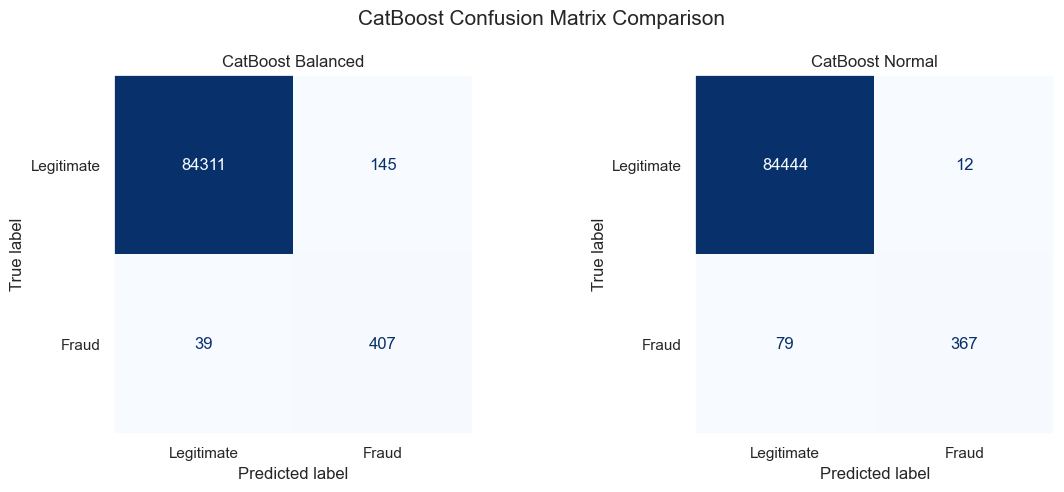

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Balanced model confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
disp_balanced = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Legitimate", "Fraud"]
)
disp_balanced.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("CatBoost Balanced")

# Normal model confusion matrix
cm_normal = confusion_matrix(y_test, y_pred_normal)
disp_normal = ConfusionMatrixDisplay(
    confusion_matrix=cm_normal,
    display_labels=["Legitimate", "Fraud"]
)
disp_normal.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("CatBoost Normal")

for ax in axes:
    ax.grid(False)

plt.suptitle("CatBoost Confusion Matrix Comparison", fontsize=15)
plt.tight_layout()
plt.show()


## ROC Curve 

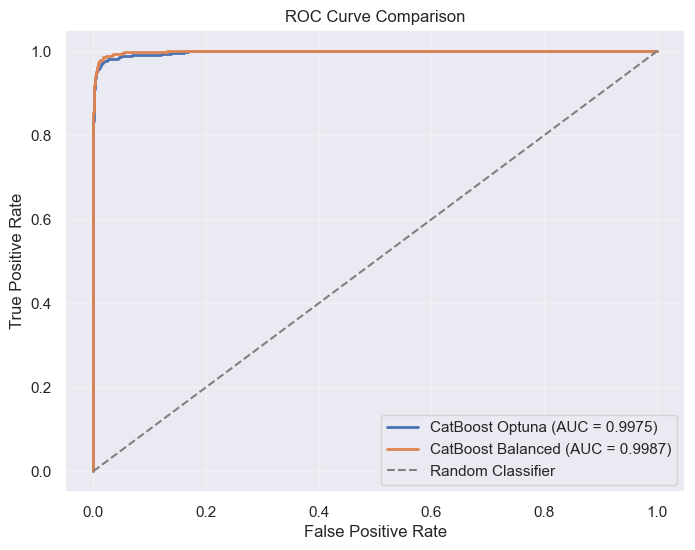

In [52]:
# ROC curve values
fpr_normal, tpr_normal, _   = roc_curve(y_test, y_prob_normal)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_prob_balanced)

# AUC scores
auc_normal   = roc_auc_score(y_test, y_prob_normal)
auc_balanced = roc_auc_score(y_test, y_prob_balanced)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_normal, tpr_normal, linewidth=2,
         label=f"CatBoost Optuna (AUC = {auc_normal:.4f})")

plt.plot(fpr_balanced, tpr_balanced, linewidth=2,
         label=f"CatBoost Balanced (AUC = {auc_balanced:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Probability Calibration 

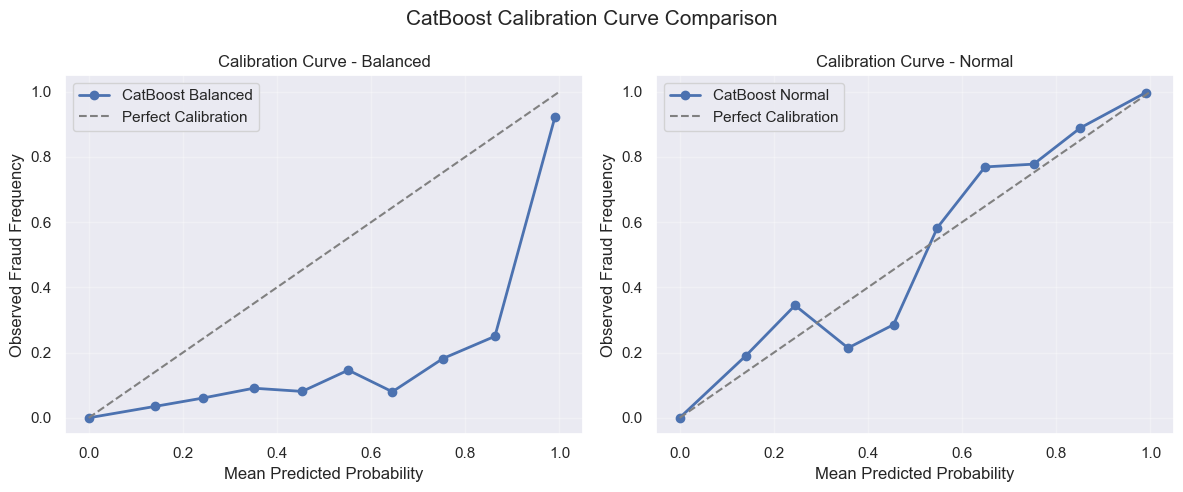

In [18]:
# Calibration curves
prob_true_balanced, prob_pred_balanced = calibration_curve(
    y_test,
    y_prob_balanced,
    n_bins=10,
    strategy="uniform"
)

prob_true_normal, prob_pred_normal = calibration_curve(
    y_test,
    y_prob_normal,
    n_bins=10,
    strategy="uniform"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Balanced model calibration curve
axes[0].plot(prob_pred_balanced, prob_true_balanced, marker="o", linewidth=2, label="CatBoost Balanced")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[0].set_title("Calibration Curve - Balanced")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Observed Fraud Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Normal model calibration curve
axes[1].plot(prob_pred_normal, prob_true_normal, marker="o", linewidth=2, label="CatBoost Normal")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[1].set_title("Calibration Curve - Normal")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Fraud Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("CatBoost Calibration Curve Comparison", fontsize=15)
plt.tight_layout()
plt.show()


The balanced CatBoost model exhibits poorer probability calibration than the standard CatBoost model, it provides superior fraud detection performance after threshold optimization. Since the primary objective of this project is accurate fraud classification rather than precise probability estimation, the balanced model was selected as the final model.

In [20]:
brier1 = brier_score_loss(y_test, y_prob_normal)
brier2 = brier_score_loss(y_test, y_prob_balanced)

print(f"Brier Score Normal: {brier1:.6f}")
print(f"Brier Score Balanced : {brier2:.6f}")

Brier Score Normal: 0.000936
Brier Score Balanced : 0.001622


The probability calibration of both CatBoost models was evaluated using the Brier Score and reliability diagrams.

The standard Optuna model achieved a lower **Brier Score (0.000938)** than the balanced model (**0.001622**), indicating more reliable probability estimates. The reliability diagrams also showed that the standard model follows the ideal calibration line more closely, whereas the balanced model tends to be overconfident due to the use of automatic class weights.

Although the standard model is better calibrated, the balanced model achieved superior fraud detection performance after threshold optimization.

## SHAP Analysis


In [21]:
explainer1 = shap.TreeExplainer(catboost_optuna)
shap_values = explainer1.shap_values(X_test)

explainer2 = shap.TreeExplainer(catboost_optuna_balanced)
shap_values_balanced = explainer2.shap_values(X_test)

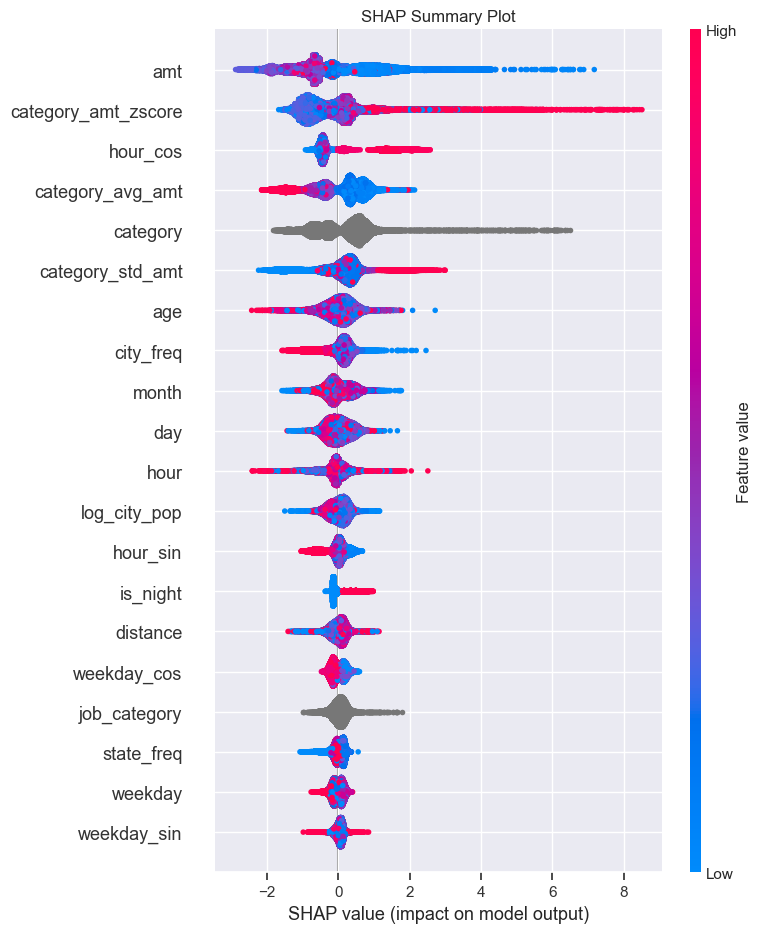

In [22]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

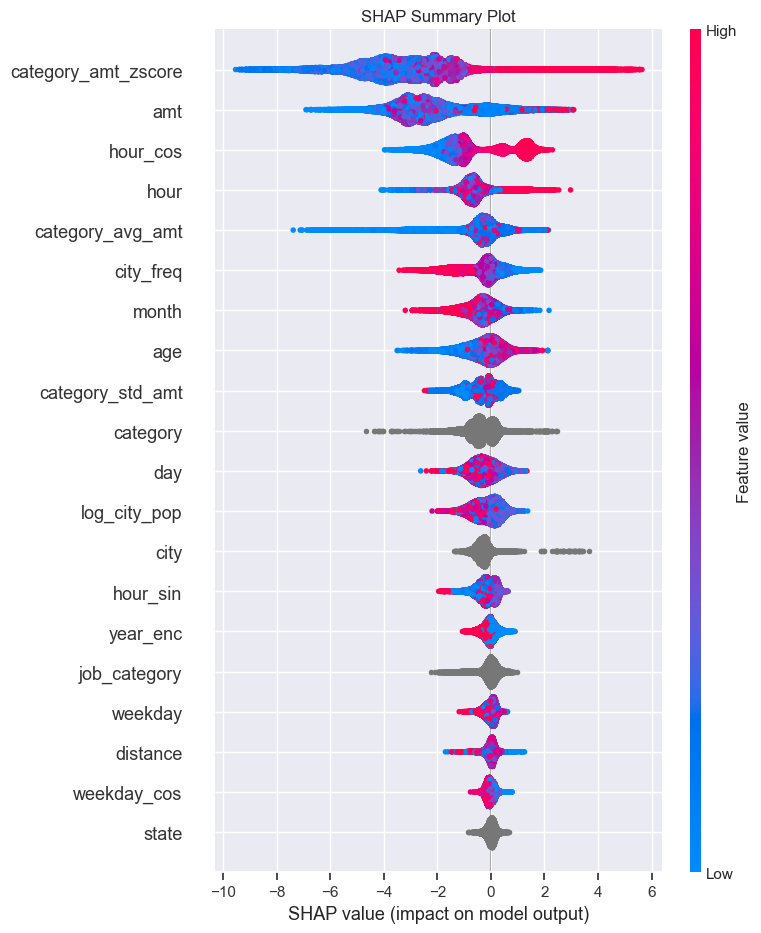

In [23]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_balanced,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

The results show that both the standard and balanced models rely on a similar set of key features, including `category_amt_zscore`, `amt`, `hour_cos`, and `category_avg_amt`, indicating that the underlying fraud detection patterns remain consistent after applying class weighting.


The balanced model exhibits a wider range of SHAP values, suggesting that it makes more confident predictions by assigning greater importance to influential features. This behavior aligns with the earlier evaluation, where the balanced model achieved higher recall at the cost of reduced probability calibration. Overall, SHAP confirms that transaction amount, deviations from typical category spending, and transaction timing are the primary drivers of fraud predictions.

## SHAP Waterfall Plot

In [38]:
threshold = 0.50

# Predictions
y_pred_normal   = (y_prob_normal   >= threshold).astype(int)
y_pred_balanced = (y_prob_balanced >= threshold).astype(int)

# True Positives
tp_idx   = np.where((y_test == 1) & (y_pred_normal   == 1))[0]
tp_idx_b = np.where((y_test == 1) & (y_pred_balanced == 1))[0]

print(f"Correctly Predicted Frauds (Normal):   {len(tp_idx)}")
print(f"Correctly Predicted Frauds (Balanced): {len(tp_idx_b)}")

Correctly Predicted Frauds (Normal):   367
Correctly Predicted Frauds (Balanced): 407


In [40]:
sample_idx = tp_idx[0]
sample_idx_b = tp_idx_b[0]

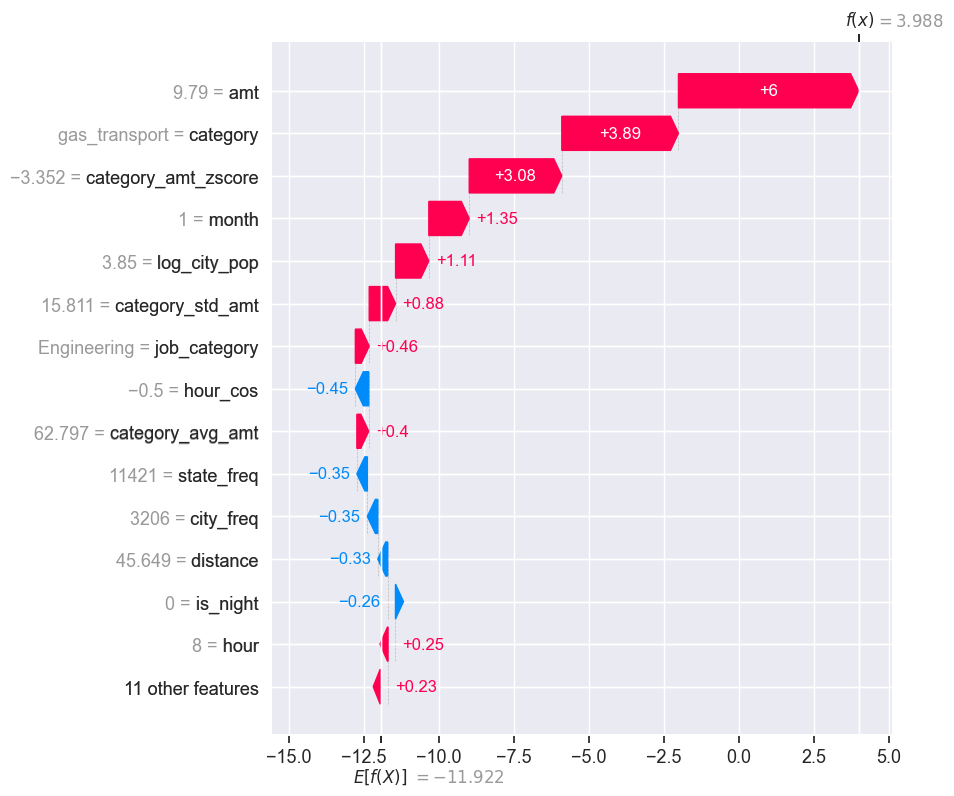

In [31]:
normal_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer1.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(
    normal_explanation,
    max_display=15
)

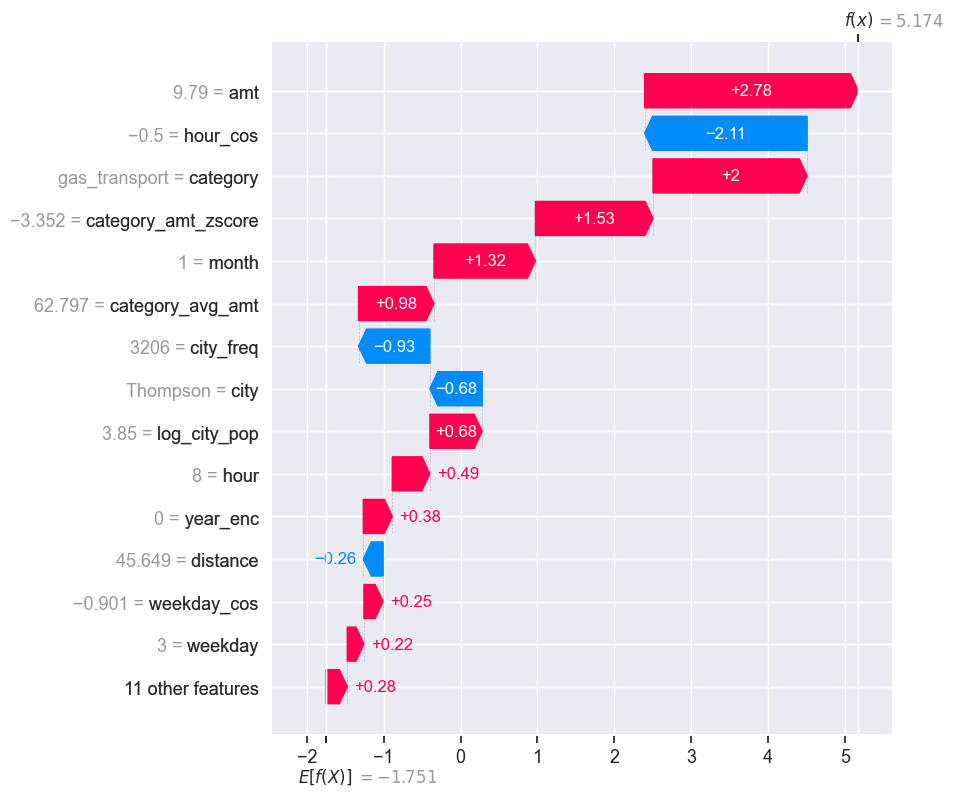

In [37]:
balanced_explanation = shap.Explanation(
    values=shap_values_balanced[sample_idx_b],
    base_values=explainer2.expected_value,
    data=X_test.iloc[sample_idx_b],
    feature_names=X_test.columns
)

shap.plots.waterfall(
    balanced_explanation,
    max_display=15
)

A SHAP Waterfall Plot was generated for a correctly classified fraudulent transaction to explain the model's decision at the individual prediction level.

The transaction amount (`amt`) was the largest positive contributor, followed by the merchant category (`gas_transport`) and the category amount z-score (`category_amt_zscore`), indicating that unusual spending behavior within this merchant category strongly increased the predicted fraud risk. Additional contributions from the transaction month and the average category transaction amount further reinforced the fraud prediction.

Conversely, temporal features such as `hour_cos`, along with location-based features including `city_freq` and `city`, reduced the fraud score by indicating patterns commonly associated with legitimate transactions. Despite these mitigating factors, the combined positive contributions were substantially larger, resulting in a high fraud prediction.

This analysis demonstrates how SHAP provides transparent, instance-level explanations by quantifying the influence of each feature on the model's final decision.

### Feature Importance Comparison


In [50]:
cat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "CatBoost Importance": catboost_optuna_balanced.get_feature_importance()
})

cat_importance = cat_importance.sort_values(
    by="CatBoost Importance",
    ascending=False
)
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": np.abs(shap_values_balanced).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)



In [43]:
comparison = cat_importance.merge(
    shap_importance,
    on="Feature"
)

comparison = comparison.sort_values(
    by="CatBoost Importance",
    ascending=False
)

comparison.head(15)

,Feature,CatBoost Importance,SHAP Importance
0,category_amt_zscore,20.622849,3.306673
1,amt,18.588759,2.282189
2,category_avg_amt,10.253234,0.615715
3,age,6.481115,0.505457
4,category,5.344783,0.442925
5,month,4.921722,0.516653
6,day,4.642940,0.427703
7,hour,4.342771,0.717212
8,category_std_amt,3.664120,0.483560
9,log_city_pop,3.571197,0.398049


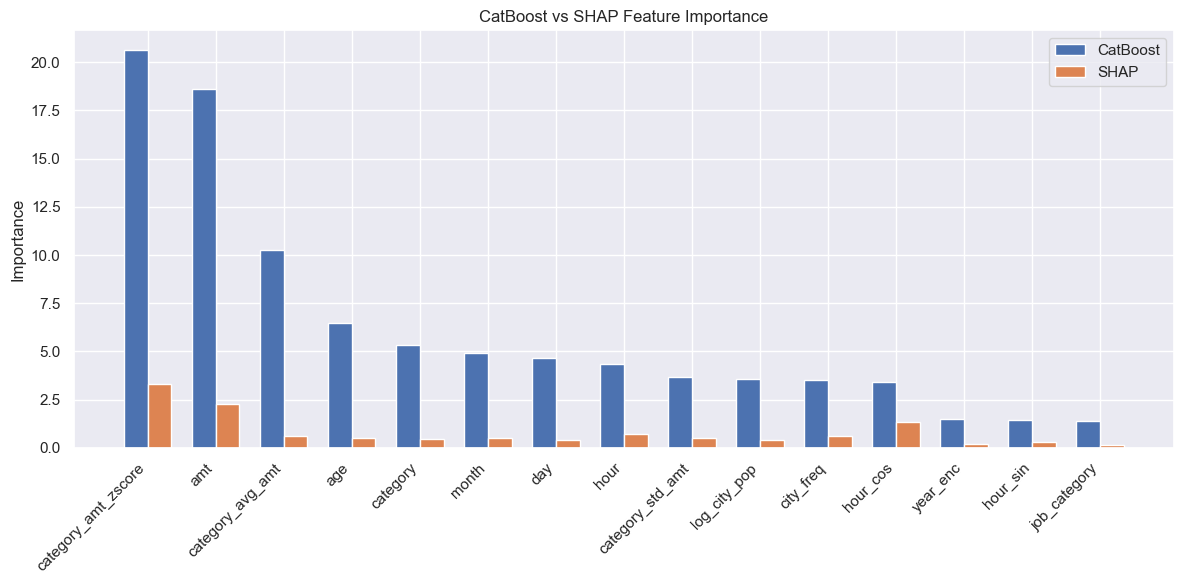

In [48]:
top_features = comparison.head(15)
x = np.arange(len(top_features))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    top_features["CatBoost Importance"],
    width,
    label="CatBoost"
)

plt.bar(
    x + width/2,
    top_features["SHAP Importance"],
    width,
    label="SHAP"
)

plt.xticks(
    x,
    top_features["Feature"],
    rotation=45,
    ha="right"
)

plt.ylabel("Importance")
plt.title("CatBoost vs SHAP Feature Importance")
plt.legend()

plt.tight_layout()
plt.show()

- Both CatBoost and SHAP consistently identify **`category_amt_zscore`** and **`amt`** as the most influential features for fraud detection.
- The strong agreement between the two methods indicates that the model has learned stable and reliable fraud patterns.
- CatBoost measures feature importance based on training, while SHAP explains each feature's contribution to individual predictions.
- Overall, SHAP validates the model's built-in feature importance and enhances the interpretability of the final fraud detection model.

In [54]:
joblib.dump(catboost_optuna_balanced, "models/catboost/catboost_final.pkl")

['models/catboost/catboost_final.pkl']